In [26]:
%pip install torch torchvision opencv-python matplotlib scikit-learn pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

In [28]:
import pandas as pd
import os
import shutil
from sklearn.model_selection import train_test_split

# Load CSV
df = pd.read_csv("labels.csv")

# Clean column names (remove spaces if needed)
df.columns = df.columns.str.strip()

# Map labels to folder names
df['label_folder'] = df['Label'].map({
    'GON+': 'positive',
    'GON-': 'negative'
})

# Get unique patients
patients = df['Patient'].unique()

# Split patients
train_p, temp_p = train_test_split(patients, test_size=0.3, random_state=42)
val_p, test_p = train_test_split(temp_p, test_size=0.5, random_state=42)

# Folder structure
base_dir = "dataset"

for split in ["train", "val", "test"]:
    for label in ["positive", "negative"]:
        os.makedirs(os.path.join(base_dir, split, label), exist_ok=True)

# Source images folder 
src_folder = "Images"   

# Copy images
for _, row in df.iterrows():
    patient = row['Patient']
    img_name = row['Image Name']
    label = row['label_folder']

    # Decide split
    if patient in train_p:
        split = "train"
    elif patient in val_p:
        split = "val"
    else:
        split = "test"

    src = os.path.join(src_folder, img_name)
    dst = os.path.join(base_dir, split, label, img_name)

    if os.path.exists(src):
        shutil.copy(src, dst)
    else:
        print(f"Missing file: {img_name}")

In [29]:
# def crop_black_border(img):
#     import numpy as np
    
#     img = np.array(img)
#     gray = img.mean(axis=2)
    
#     coords = np.where(gray > 10)
    
#     y_min, y_max = coords[0].min(), coords[0].max()
#     x_min, x_max = coords[1].min(), coords[1].max()
    
#     return img[y_min:y_max, x_min:x_max]

In [30]:
from PIL import Image

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [31]:
train_dataset = datasets.ImageFolder("dataset/train", transform=train_transform)
val_dataset = datasets.ImageFolder("dataset/val", transform=val_transform)
test_dataset = datasets.ImageFolder("dataset/test", transform=val_transform)

In [32]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [33]:
print(train_dataset.class_to_idx)

{'negative': 0, 'positive': 1}


In [34]:
model = torchvision.models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 2)

c:\Users\Asus A1404\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Asus A1404\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

weights = torch.tensor([2.7, 1.0]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [36]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

patience = 3
counter = 0

for epoch in range(25 ):

    # TRAIN
    model.train()
    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss) 

    print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("Saved Best Model")
        counter = 0   # reset if improved
    else:
        counter += 1  # no improvement

    if counter >= patience:
        print("Early stopping triggered")
        break

    

Epoch 1: Train Loss 0.2094 | Val Loss 0.2936
Saved Best Model
Epoch 2: Train Loss 0.1218 | Val Loss 0.2714
Saved Best Model
Epoch 3: Train Loss 0.0621 | Val Loss 0.4386
Epoch 4: Train Loss 0.0627 | Val Loss 0.1976
Saved Best Model
Epoch 5: Train Loss 0.0717 | Val Loss 0.1922
Saved Best Model
Epoch 6: Train Loss 0.0434 | Val Loss 0.1875
Saved Best Model
Epoch 7: Train Loss 0.0271 | Val Loss 0.1975
Epoch 8: Train Loss 0.0663 | Val Loss 0.2576
Epoch 9: Train Loss 0.0385 | Val Loss 0.1766
Saved Best Model
Epoch 10: Train Loss 0.0153 | Val Loss 0.1881
Epoch 11: Train Loss 0.0052 | Val Loss 0.1896
Epoch 12: Train Loss 0.0184 | Val Loss 0.1993
Early stopping triggered


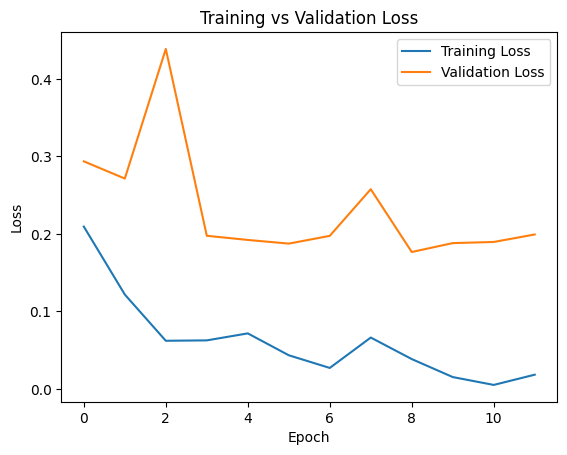

In [37]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [60]:
from sklearn.metrics import classification_report

y_true = []
y_scores = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:,1]

        y_true.extend(labels.numpy())
        y_scores.extend(probs.cpu().numpy())

# AFTER collecting scores
thresholds = [0.15, 0.2, 0.25, 0.3]

for t in thresholds:
    y_pred = [1 if p > t else 0 for p in y_scores]
    print(f"\nThreshold: {t}")
    print(classification_report(y_true, y_pred))


Threshold: 0.15
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        23
           1       0.96      0.96      0.96        75

    accuracy                           0.94        98
   macro avg       0.91      0.91      0.91        98
weighted avg       0.94      0.94      0.94        98


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.88      0.91      0.89        23
           1       0.97      0.96      0.97        75

    accuracy                           0.95        98
   macro avg       0.92      0.94      0.93        98
weighted avg       0.95      0.95      0.95        98


Threshold: 0.25
              precision    recall  f1-score   support

           0       0.84      0.91      0.88        23
           1       0.97      0.95      0.96        75

    accuracy                           0.94        98
   macro avg       0.91      0.93      0.92        98
weighted avg       0.94 

In [39]:
torch.save(model.state_dict(), "best_model.pth")

In [40]:
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

y_scores = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:,1]

        y_scores.extend(probs.cpu().numpy())

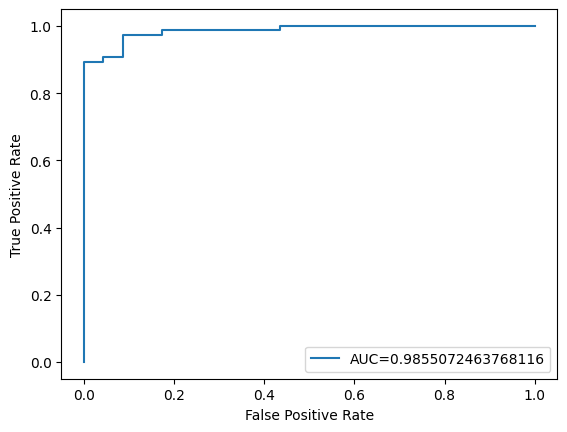

In [41]:
from matplotlib import pyplot as plt


fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC="+str(roc_auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [42]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)

AUC: 0.9855072463768116


GRAD-CAM

In [43]:
%pip install grad-cam

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18()

model.fc = torch.nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load("glaucoma_model.pth", map_location=device))

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [46]:
target_layer = model.layer4[-1]

In [47]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

img = Image.open("dataset/test/positive/5_0.jpg").convert("RGB")

input_tensor = transform(img).unsqueeze(0)

In [48]:
img_np = np.array(img.resize((224,224))) / 255.0

In [49]:
cam = GradCAM(model=model, target_layers=[target_layer])

grayscale_cam = cam(
    input_tensor=input_tensor,
    aug_smooth=True,
    eigen_smooth=True
)

cam_image = show_cam_on_image(img_np, grayscale_cam[0], use_rgb=True)

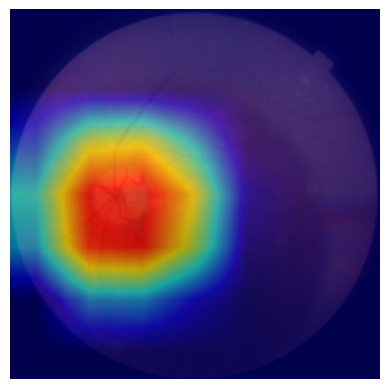

In [50]:
plt.imshow(cam_image)
plt.axis("off")
plt.show()